# 05 - Transfer Learning with ResNet-18
Goal: fine-tune a pretrained ResNet-18 on DermaMNIST instead of training from scratch,
and compare against the scratch TinyNet baseline. Also add a fixed random seed for reproducibility.

In [1]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)
print("seed set - runs are now reproducible")

seed set - runs are now reproducible


## What is transfer learning
Instead of training from scratch, start from a model that already learned to see.
- ResNet-18 was trained on ImageNet (1.2M images, 1000 classes), so it already extracts good visual
  features: edges, textures, shapes. These are general and useful for ANY image task, including skin lesions.
- We reuse that: keep ResNet's feature-extraction, swap only its final layer (1000 classes -> our 7),
  and fine-tune on DermaMNIST.
- Should beat TinyNet, which had to learn everything from just 7007 images.
Analogy: hiring a trained cook and teaching them your menu, vs training a cook from zero.

In [2]:
from torchvision import models

resnet = models.resnet18(weights="IMAGENET1K_V1")   # download ResNet-18 with its ImageNet-trained weights

print(resnet.fc)   # the final layer - the one we'll replace

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\study/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 12.3MB/s]


Linear(in_features=512, out_features=1000, bias=True)


In [3]:
import torch.nn as nn

resnet.fc = nn.Linear(512, 7)   # replace 1000-class head with a fresh 7-class one

print(resnet.fc)

Linear(in_features=512, out_features=7, bias=True)


## Swapping the head
Replaced ResNet's final layer: Linear(512, 1000) -> Linear(512, 7).
- Keep the body (all feature-extraction layers, already trained on ImageNet).
- 512 = ResNet's feature-vector size (must match). 7 = our classes.
- The new head starts random; it is the only part that must learn from scratch.
Essence of transfer learning: keep the body, replace the head.

In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

resnet_transform = transforms.Compose([
    transforms.Resize(224),                        # ResNet expects ~224x224, not 28x28
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet's normalisation stats
                         std=[0.229, 0.224, 0.225]),
])

train_data = DermaMNIST(split="train", download=True, size=28, transform=resnet_transform)
val_data   = DermaMNIST(split="val",   download=True, size=28, transform=resnet_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

print("resnet data ready")

resnet data ready


## Data adjustments for ResNet
Pretrained models need their inputs to match how they were originally trained:
- Resize to 224x224 (ResNet's expected input size, not 28x28).
- Normalize with ImageNet's stats [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225] - a pretrained model
  expects its original normalisation, or its learned features misfire.
- batch_size=32 (down from 64): 224x224 images use much more memory.

In [6]:
set_seed(42)   # reproducibility, before we build/train

# freeze every parameter in the body
for param in resnet.parameters():
    param.requires_grad = False

# unfreeze ONLY the new head (re-create it so it's fresh + trainable)
resnet.fc = nn.Linear(512, 7)

# confirm what is trainable
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"trainable params: {trainable:,} out of {total:,}")

trainable params: 3,591 out of 11,180,103


## Freezing the body
Froze all ResNet body params (`requires_grad = False`), train only the new head.
- Trainable: 3,591 out of 11.2M params (0.03%) - this is what makes ResNet runnable on CPU.
- Frozen layers skip gradient computation and updates (the requires_grad flag from notebook 01, used deliberately).
- Trade-off: freezing = fast, little data, body stays as ImageNet shaped it. Unfreezing = slower, needs more
  data, but body adapts to skin lesions. With a GPU I would unfreeze and fine-tune the whole network.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)   # ONLY the head's params

for epoch in range(3):
    resnet.train()
    running_loss = 0.0
    for images, labels in train_loader:
        labels = labels.squeeze()
        logits = resnet(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch}  train loss {running_loss/len(train_loader):.4f}")

epoch 0  train loss 0.9064
epoch 1  train loss 0.7827
epoch 2  train loss 0.7487


## Training the head (results)
Same loop as before, frozen ResNet, optimizer gets ONLY the head's params. 3 epochs.
Train loss: 0.91 -> 0.78 -> 0.75.
- Freezing skips the BACKWARD pass for the body, but the forward pass still runs through the whole
  network, which is why each epoch is slow on CPU (several minutes).
- Only the head (3,591 params) is learning; the ImageNet-trained body is fixed.
Train loss alone does not tell us if it beat TinyNet - checked on validation next.

In [8]:
resnet.eval()
correct = total = 0
per_class_correct = [0]*7
per_class_total = [0]*7

with torch.no_grad():
    for images, labels in val_loader:
        labels = labels.squeeze()
        preds = resnet(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        for c in range(7):
            mask = (labels == c)
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += (preds[mask] == c).sum().item()

print(f"overall val accuracy: {100*correct/total:.1f}%\n")
for c in range(7):
    recall = 100*per_class_correct[c]/per_class_total[c] if per_class_total[c] else 0
    print(f"class {c}: {per_class_correct[c]:3d}/{per_class_total[c]:3d}  ({recall:4.1f}% recall)")

overall val accuracy: 75.0%

class 0:  22/ 33  (66.7% recall)
class 1:   9/ 52  (17.3% recall)
class 2:  29/110  (26.4% recall)
class 3:   4/ 12  (33.3% recall)
class 4:  47/111  (42.3% recall)
class 5: 638/671  (95.1% recall)
class 6:   3/ 14  (21.4% recall)


## ResNet results vs TinyNet (three-way comparison)

| Class | TinyNet baseline | TinyNet weighted | ResNet frozen |
|---|---|---|---|
| 0 (actinic keratoses) | 15.2% | 42.4% | 66.7% |
| 1 (basal cell carcinoma) | 55.8% | 57.7% | 17.3% |
| 2 (benign keratosis) | 26.4% | 41.8% | 26.4% |
| 3 (dermatofibroma) | 0.0% | 25.0% | 33.3% |
| 4 (melanoma) | 18.9% | 37.8% | 42.3% |
| 5 (nevi, majority) | 94.6% | 50.4% | 95.1% |
| 6 (vascular) | 21.4% | 71.4% | 21.4% |
| **overall accuracy** | **72.0%** | **48.2%** | **75.0%** |

ResNet wins on overall accuracy (75%) and melanoma recall (42.3%) even WITHOUT weighting - its ImageNet
features are far stronger than TinyNet's, which had to learn everything from 7007 images.

BUT ResNet still leans heavily on the majority class (nevi 95.1%), the same imbalance pattern as the
TinyNet baseline. Better features did NOT solve imbalance - its rare-class recall is uneven (strong on
class 0 and melanoma, weak on classes 1, 2, 6).

Key insight: feature quality and imbalance handling are SEPARATE problems. Transfer learning raised the
ceiling (accuracy + melanoma) but imbalance is orthogonal and still needs addressing.

# ResNet + weighted loss

In [9]:
import numpy as np

labels_all = train_data.labels.flatten()
classes, counts = np.unique(labels_all, return_counts=True)

weights = 1.0 / counts
weights = weights / weights.sum() * len(classes)
class_weights = torch.tensor(weights, dtype=torch.float32)

print("class weights:", class_weights)

class weights: tensor([0.9426, 0.5987, 0.2795, 2.6865, 0.2759, 0.0458, 2.1709])


## Recompute class weights (for this notebook)
Same inverse-frequency weights as notebook 04 (class 3 = 2.69, class 5 = 0.05).
Weights depend only on labels, so the ResNet transform does not affect them.

In [10]:
set_seed(42)

# fresh frozen ResNet with a new head (clean start for a fair comparison)
resnet_w = models.resnet18(weights="IMAGENET1K_V1")
for param in resnet_w.parameters():
    param.requires_grad = False
resnet_w.fc = nn.Linear(512, 7)

criterion = nn.CrossEntropyLoss(weight=class_weights)   # <-- weighted, the only change from before
optimizer = torch.optim.Adam(resnet_w.fc.parameters(), lr=1e-3)

for epoch in range(3):
    resnet_w.train()
    running_loss = 0.0
    for images, labels in train_loader:
        labels = labels.squeeze()
        logits = resnet_w(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch}  train loss {running_loss/len(train_loader):.4f}")

epoch 0  train loss 1.6198
epoch 1  train loss 1.3270
epoch 2  train loss 1.2412


## Train ResNet head with weighted loss
Fresh frozen ResNet, new head, identical loop - the ONLY change is CrossEntropyLoss(weight=class_weights).
This isolates the effect of weighting (one variable changed), completing the 2x2:
{TinyNet, ResNet} x {plain, weighted}.

Train loss: 1.62 -> 1.33 -> 1.24 (higher than plain ResNet's 0.75, as expected - weighting makes
rare-class mistakes cost more, so the loss counts failures the plain model ignored).

In [11]:
resnet_w.eval()
correct = total = 0
per_class_correct = [0]*7
per_class_total = [0]*7

with torch.no_grad():
    for images, labels in val_loader:
        labels = labels.squeeze()
        preds = resnet_w(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        for c in range(7):
            mask = (labels == c)
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += (preds[mask] == c).sum().item()

print(f"overall val accuracy: {100*correct/total:.1f}%\n")
for c in range(7):
    recall = 100*per_class_correct[c]/per_class_total[c] if per_class_total[c] else 0
    print(f"class {c}: {per_class_correct[c]:3d}/{per_class_total[c]:3d}  ({recall:4.1f}% recall)")

overall val accuracy: 54.0%

class 0:  23/ 33  (69.7% recall)
class 1:  30/ 52  (57.7% recall)
class 2:  28/110  (25.5% recall)
class 3:   5/ 12  (41.7% recall)
class 4:  62/111  (55.9% recall)
class 5: 383/671  (57.1% recall)
class 6:  11/ 14  (78.6% recall)


## Final four-way comparison (2x2 complete)

| Class | TinyNet base | TinyNet weighted | ResNet plain | ResNet weighted |
|---|---|---|---|---|
| 0 (actinic keratoses) | 15.2% | 42.4% | 66.7% | 69.7% |
| 1 (basal cell carcinoma) | 55.8% | 57.7% | 17.3% | 57.7% |
| 2 (benign keratosis) | 26.4% | 41.8% | 26.4% | 25.5% |
| 3 (dermatofibroma) | 0.0% | 25.0% | 33.3% | 41.7% |
| 4 (melanoma) | 18.9% | 37.8% | 42.3% | 55.9% |
| 5 (nevi, majority) | 94.6% | 50.4% | 95.1% | 57.1% |
| 6 (vascular) | 21.4% | 71.4% | 21.4% | 78.6% |
| **overall accuracy** | 72.0% | 48.2% | 75.0% | 54.0% |

Melanoma recall across the four: 18.9% -> 37.8% -> 42.3% -> 55.9%. The combined model (ResNet + weighted)
catches the most melanomas of any configuration, and stays balanced across rare classes without collapsing
onto the majority (nevi 57% vs plain ResNet's 95%).

Conclusion: the two techniques STACK. Transfer learning raised the ceiling (better features); weighting
redistributed attention to rare classes. Together they beat either alone on the metric that matters most
for screening (rare-class / melanoma recall). For deployment, ResNet + weighted loss is the model to pick:
lower headline accuracy than plain ResNet, but far more useful where the stakes are highest.

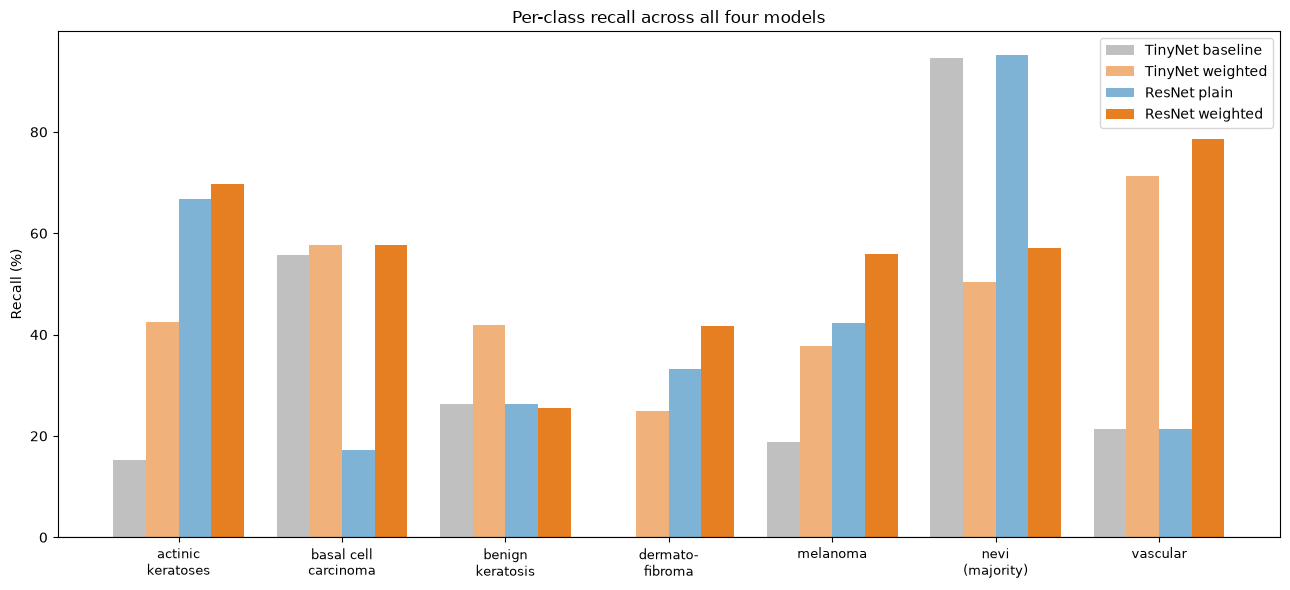

In [12]:
import matplotlib.pyplot as plt

class_names = ["actinic\nkeratoses", "basal cell\ncarcinoma", "benign\nkeratosis",
               "dermato-\nfibroma", "melanoma", "nevi\n(majority)", "vascular"]

tinynet_base = [15.2, 55.8, 26.4, 0.0, 18.9, 94.6, 21.4]
tinynet_wt   = [42.4, 57.7, 41.8, 25.0, 37.8, 50.4, 71.4]
resnet_base  = [66.7, 17.3, 26.4, 33.3, 42.3, 95.1, 21.4]
resnet_wt    = [69.7, 57.7, 25.5, 41.7, 55.9, 57.1, 78.6]

x = np.arange(len(class_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - 1.5*width, tinynet_base, width, label="TinyNet baseline", color="#c0c0c0")
ax.bar(x - 0.5*width, tinynet_wt,   width, label="TinyNet weighted", color="#f0b27a")
ax.bar(x + 0.5*width, resnet_base,  width, label="ResNet plain",     color="#7fb3d5")
ax.bar(x + 1.5*width, resnet_wt,    width, label="ResNet weighted",  color="#e67e22")

ax.set_ylabel("Recall (%)")
ax.set_title("Per-class recall across all four models")
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=9)
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("four_way_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the four-way chart
Orange (ResNet weighted) is tallest or near-tallest on the rare/dangerous classes (melanoma, dermatofibroma,
vascular, actinic) while the majority class (nevi) drops from the towering grey/blue plain-model bars.
The plain models (grey, blue) spike on nevi; the weighted models (light/dark orange) trade that for
balanced rare-class coverage. Visually confirms: features + weighting together give the best screening model.